# Schroeder Problem 7.16

Consider an isolated system of N identical fermions, inside a container
where the allowed energy levels are nondegenerate and evenly spaced. For
instance, the fermions could be trapped in a one-dimensional harmonic oscillator
potential. For simplicity, neglect the fact that fermions can have multiple spin
orientations (or assume that they are all forced to have the same spin orientation).
Then each energy level is either occupied or unoccupied, and any allowed system
state can be represented by a column of dots, with a filled dot representing an occupied
level and a hollow dot representing an unoccupied level. The lowest-energy
system state has all levels below a certain point occupied, and all levels above
that point unoccupied. Let $\eta$ be the spacing between energy levels, and let $q$ be
the number of energy units (each of size $\eta$) in excess of the ground-state energy.
Assume that $q < N$. Figure 7.8 in the Schroeder text shows all system states up to $q = 3$.

(a) Draw dot diagrams, as in the figure, for all allowed system states with
q = 4, q = 5, and q = 6.

(b) According to the fundamental assumption, all allowed system states with
a given value of q are equally probable. Compute the probability of each
energy level being occupied, for q = 6. Draw a graph of this probability as
a function of the energy of the level.

(c) In the thermodynamic limit where q is large, the probability of a level being
occupied should be given by the Fermi-Dirac distribution. Even though 6
is not a large number, estimate the values of p and T that you would have
to plug into the Fermi-Dirac distribution to best fit the graph you drew in
part (b).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

In [2]:
# empirical occupation numbers
occupations = np.array((1, 1, 1, 10/11, 10/11, 9/11, 8/11, 7/11, 6/11, \
                        5/11, 4/11, 3/11, 2/11, 1/11, 1/11, 0, 0, 0, 0))
eps_pts = np.arange(1, len(occupations)+1, 1)  # integers from 1 to the no. of entries in occupations

In [3]:
def nbar_Fermi_Dirac(eps, mu, kT):
    """
    Fermi-Dirac average occupation number
    """
    return 1 / (np.exp( (eps - mu) / kT ) + 1)

/var/folders/1s/3wbqg65x5k79l5ww8fg25yvh0000gn/T/ipykernel_73481/52349534.py:5: RuntimeWarning: overflow encountered in exp
  return 1 / (np.exp( (eps - mu) / kT ) + 1)


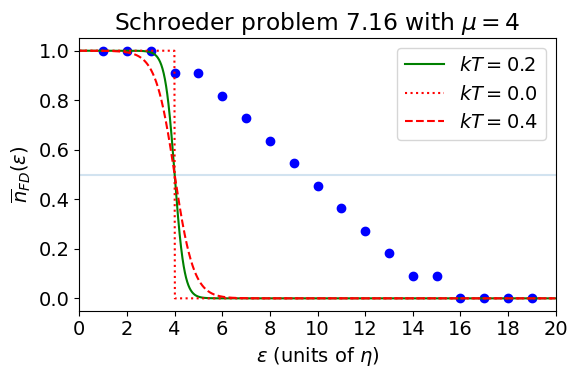

In [6]:
# try values for mu and kT, plotting nbar_FD vs. energy eps
kT = 0.2001 # 4  # .20001  #2  #5 # 0.2001 # 5 # 2  # in units of eta
mu = 4 # 9.5  # in units of eta
eps_full = np.arange(0, 20, 0.01)
delta_kT = 0.2  # plot for kT, kT - delta_kT,  and kT + delta_kT

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(1,1,1)

ax.axhline(0.5, alpha=0.2)  # line to use to find mu

ax.plot(eps_pts, occupations, 'o', color='blue', )
ax.plot(eps_full, nbar_Fermi_Dirac(eps_full, mu, kT), label=rf'$kT = {kT:.1f}$', color='green')
ax.plot(eps_full, nbar_Fermi_Dirac(eps_full, mu, kT-delta_kT), ls=':', label=rf'$kT = {kT-delta_kT:.1f}$', color='red')
ax.plot(eps_full, nbar_Fermi_Dirac(eps_full, mu, kT+delta_kT), ls='--', label=rf'$kT = {kT+delta_kT:.1f}$', color='red')

ax.set_xlabel(r'$\epsilon$ (units of $\eta$)')
ax.set_ylabel(r'$\overline{n}_{FD}(\epsilon)$')
ax.set_title(rf'Schroeder problem 7.16 with $\mu = {mu}$')

ax.set_xticks(np.arange(0, 20.1, 2))
ax.set_xlim(0,20)

ax.legend()
fig.tight_layout()